#

In [ ]:
---
execute:
  eval: false
  echo: true
  warning: false
format:
  html:
    code-fold: false
---

Importing the packages.

In [3]:
import torch
import deepinv as dinv
from torchvision import datasets, transforms
from diffusers import DDPMPipeline
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Creating an inpainting problem.

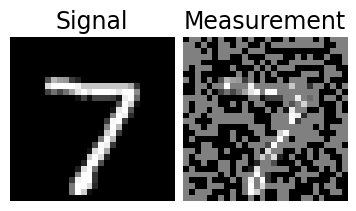

In [22]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
mnist = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

x_true = mnist[0][0].unsqueeze(0).to(device)

sigma = 0.001
physics = dinv.physics.Inpainting(
    mask=0.5,
    img_size=x_true.shape[1:],
    noise_model=dinv.physics.GaussianNoise(sigma=sigma),
    device=device,
)

y = physics(x_true)

dinv.utils.plotting.plot([x_true, y], titles=["Signal", "Measurement"])

Loading a pre-trained MNIST Diffusion Model.

In [ ]:
pipeline = DDPMPipeline.from_pretrained("1aurent/ddpm-mnist").to(device)
unet = pipeline.unet
scheduler = pipeline.scheduler
scheduler.set_timesteps(1000)
alphas_cumprod = scheduler.alphas_cumprod.to(device)

Reconstructing the image using DPS.

In [ ]:
rho = 0.005
data_fidelity = dinv.optim.data_fidelity.L1()

x_t = torch.randn_like(x_true)

for i, t in enumerate(scheduler.timesteps):
    x_t = x_t.requires_grad_(True)
    noise_pred = unet(x_t, t).sample

    alpha_bar = alphas_cumprod[t]
    x_hat_0 = (x_t - (1 - alpha_bar).sqrt() * noise_pred) / alpha_bar.sqrt()

    loss = data_fidelity(x_hat_0, y, physics)

    grad = torch.autograd.grad(outputs=loss, inputs=x_t)[0]

    with torch.no_grad():
        prev_sample = scheduler.step(noise_pred, t, x_t).prev_sample

    x_t = (prev_sample - rho * grad).detach()

x_recon = x_t

Plotting the results.

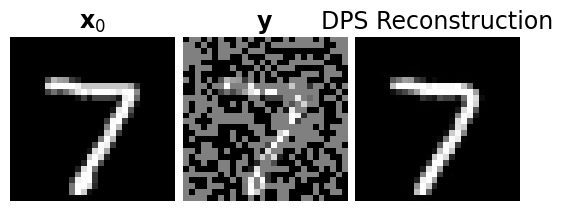

In [24]:
imgs = [x_true, y, x_recon]
titles = [r"$\mathbf{x}_0$", r"$\mathbf{y}$", r"DPS Reconstruction"]

dinv.utils.plotting.plot(imgs, titles=titles, cmap="gray")